# 00b — Intuición visual de Policy Gradients

**Módulo:** `src/llm_rlhf/highway.py` → `WindyHighway`

Antes de aplicar policy gradients a un LLM (donde el *policy* es opaco y la trayectoria es una secuencia de tokens), vale la pena verlos funcionar en un problema que se puede *dibujar*. Este notebook adapta el ejemplo *Windy Highway* de Duane Rich a matplotlib y, con visualizaciones explícitas, hace tangibles tres ideas que reaparecen en PPO/DPO/GRPO:

1. Un *policy* es una distribución sobre acciones condicionada al estado.
2. El gradiente de la log-verosimilitud, *escalado por el retorno*, empuja al policy hacia trayectorias con mayor recompensa (REINFORCE).
3. Restar un *baseline* (función de valor) reduce drásticamente la varianza del gradiente — la idea actor-crítico.

Cuando entiendas qué está optimizando aquí, leer `04_ppo.ipynb` será una repetición de la misma matemática con un policy mucho más grande.

## Setup (Colab o entorno nuevo)

Esta primera celda es **idempotente**: si `llm_rlhf` ya está instalado, no hace nada.

In [1]:
# (Skipped — local env already has llm_rlhf installed)

## El entorno: "Windy Highway"

El mundo es el cuadrado unitario `[0,1] × [0,1]`. El agente:

- **Empieza** en $y = 0$, con $x \sim \mathcal{U}[0.4, 0.6]$.
- En cada paso *siempre sube* un poquito en $y$. Elige una de tres acciones: `left`, `right`, `up`.
- Hay **viento** que lo empuja horizontalmente: $w(x) = w_{max} \cos(2\pi x)$. El viento es *fuerte hacia la izquierda* cerca de $x = 0$ y $x = 1$, y *fuerte hacia la derecha* cerca de $x = 0.5$.
- Recibe **recompensa** $r(x) = \sin(2\pi x)$ en cada paso. Máxima cerca de $x = 0.25$ (la *autopista de alta recompensa*), mínima cerca de $x = 0.75$ (la zanja).
- **Termina** cuando $y \geq 1$.

Visualicemos primero la recompensa y el viento. Un agente óptimo aprenderá a *navegar hacia $x = 0.25$* y mantenerse ahí, aunque a veces el viento juegue en su contra.

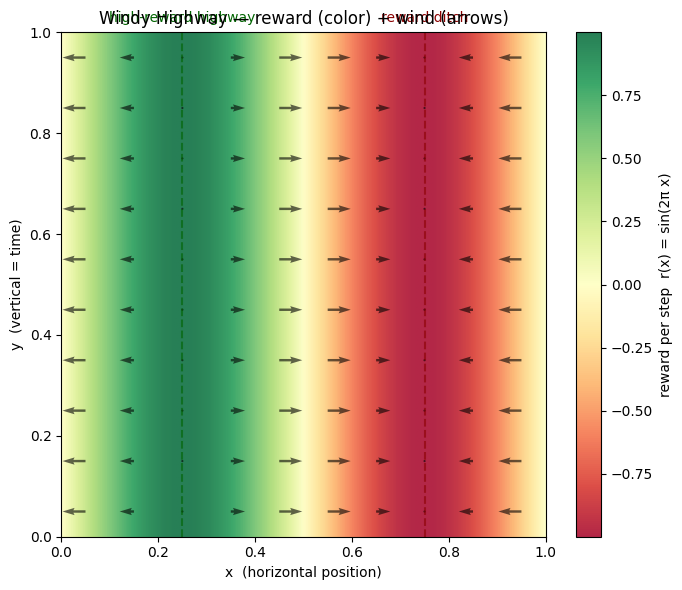

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from llm_rlhf.highway import WindyHighway

hw = WindyHighway(alpha=0.1, distance_scaler=0.15, protos_per_dim=5, seed=1)

fig, ax = plt.subplots(figsize=(7, 6))
# reward landscape
land = hw.reward_landscape(n_grid=200)
im = ax.imshow(
    land["R"], origin="lower", extent=[0, 1, 0, 1],
    cmap="RdYlGn", aspect="auto", alpha=0.85,
)
fig.colorbar(im, ax=ax, label="reward per step  r(x) = sin(2π x)")

# wind field as a quiver overlay
wf = hw.wind_field(n_grid=10)
ax.quiver(wf["X"], wf["Y"], wf["U"], wf["V"], color="black", scale=0.4, width=0.005, alpha=0.6)

# label the high/low reward bands
ax.axvline(0.25, color="darkgreen", linestyle="--", alpha=0.6)
ax.axvline(0.75, color="darkred",   linestyle="--", alpha=0.6)
ax.text(0.25, 1.02, "high-reward highway", ha="center", color="darkgreen")
ax.text(0.75, 1.02, "reward ditch",         ha="center", color="darkred")

ax.set_xlabel("x  (horizontal position)")
ax.set_ylabel("y  (vertical = time)")
ax.set_title("Windy Highway — reward (color) + wind (arrows)")
plt.tight_layout()
plt.show()

**Qué leer del gráfico:**

- La franja **verde** (autopista) está cerca de $x = 0.25$ — ahí queremos que el policy gaste su tiempo.
- La franja **roja** (zanja) está cerca de $x = 0.75$ — ahí pierde recompensa.
- Las **flechas** muestran el viento. Fíjate cómo, *empezando en $x \approx 0.5$* (donde el agente se inicia), el viento empuja hacia la derecha — alejándolo de la autopista. Una política ingenua que solo va `up` será arrastrada por el viento hacia la zanja.

Este es el problema: **el agente tiene que aprender a *luchar* contra el viento** para llegar a la región rentable.

## El policy: RBF + softmax

Parametrizamos $\pi(a \mid s)$ con un softmax sobre 3 logits (uno por acción). Cada logit es una combinación lineal de *features RBF* del estado:

$$\phi_k(s) = \frac{e^{-\|s - p_k\|^2 / \sigma^2}}{\sum_j e^{-\|s - p_j\|^2 / \sigma^2}}, \qquad \text{logit}_a(s) = \sum_k \theta_{k,a} \, \phi_k(s)$$

Las $p_k$ son **proto-puntos** dispuestos en una rejilla hexagonal. El parámetro entrenable es $\theta \in \mathbb{R}^{K \times 2}$ — una columna para `left`, otra para `right`. El logit de `up` está fijado en 0 (referencia).

> **Por qué RBFs y no una red neuronal:** queremos un policy *legible* — al pintar los proto-puntos sobre el mapa, ves directamente qué parámetros mueven al agente en cada región. La idea de "gradiente sobre log-prob" es exactamente la misma que en una red profunda; solo cambia la función de features.

Visualicemos el policy *antes* de entrenar. Como $\theta = 0$, los tres logits están en 0 y los tres movimientos son equiprobables ($\pi = (1/3, 1/3, 1/3)$ en todo punto). Las flechas tienen el mismo tamaño en todas las celdas — el agente no tiene preferencia.

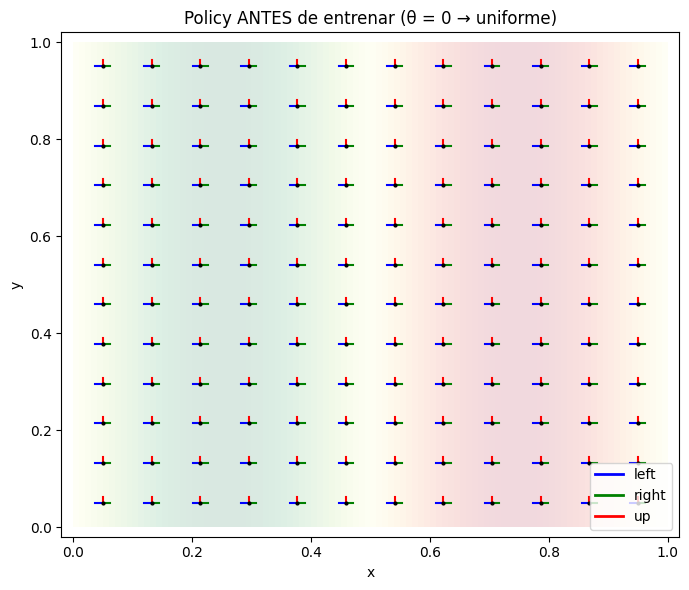

In [3]:
def plot_policy(hw, ax, title=""):
    """Plot the policy as colored arrows over a grid.

    Each grid point draws three arrows whose *lengths* equal the action
    probabilities at that state. Blue = left, green = right, red = up.
    Long arrow ⇒ confident in that action.
    """
    field = hw.policy_field(n_grid=12)
    arrow_len = (1.0 / 12) * 0.45
    for i in range(field["X"].shape[0]):
        for j in range(field["X"].shape[1]):
            x, y = field["X"][i, j], field["Y"][i, j]
            pl, pr, pu = field["left"][i, j], field["right"][i, j], field["up"][i, j]
            ax.plot([x, x - pl * arrow_len], [y, y],            color="blue",  lw=1.5)
            ax.plot([x, x + pr * arrow_len], [y, y],            color="green", lw=1.5)
            ax.plot([x, x],                  [y, y + pu * arrow_len], color="red",   lw=1.5)
            ax.scatter([x], [y], color="black", s=4, zorder=3)
    # Show the reward as a faint backdrop
    land = hw.reward_landscape(n_grid=100)
    ax.imshow(land["R"], origin="lower", extent=[0, 1, 0, 1], cmap="RdYlGn", alpha=0.15, aspect="auto")
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_title(title)

fig, ax = plt.subplots(figsize=(7, 6))
plot_policy(hw, ax, title="Policy ANTES de entrenar (θ = 0 → uniforme)")
# legend
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0],color=c,lw=2,label=l) for c,l in
                   [("blue","left"),("green","right"),("red","up")]], loc="lower right")
plt.tight_layout()
plt.show()

## Una trayectoria antes de entrenar

Con el policy uniforme, el agente camina aleatoriamente. Su única regularidad es que *siempre* sube en $y$ — así que termina (alcanza $y=1$) tras ~20 pasos. El viento, mientras tanto, lo desplaza horizontalmente.

Veamos una trayectoria y el retorno acumulado en cada paso.

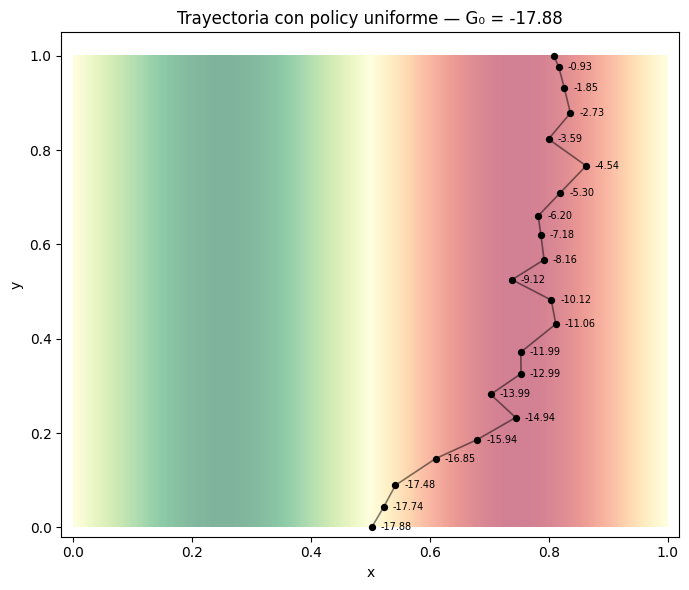

Las etiquetas en cada punto son el retorno restante G_t = Σ_{i>t} r_i.
G_0 es el retorno total del episodio — la única señal de la que aprende REINFORCE.


In [4]:
states, actions, rewards, returns = hw.play_episode()
G0 = returns[0]

fig, ax = plt.subplots(figsize=(7, 6))
land = hw.reward_landscape(n_grid=200)
ax.imshow(land["R"], origin="lower", extent=[0, 1, 0, 1], cmap="RdYlGn", alpha=0.5, aspect="auto")
ax.plot(states[:, 0], states[:, 1], color="black", lw=1.2, alpha=0.5)
ax.scatter(states[:, 0], states[:, 1], c="black", s=18, zorder=3)
for t, (x, y) in enumerate(states):
    if not np.isnan(returns[t]):
        ax.text(x + 0.015, y, f"{returns[t]:+.2f}", fontsize=7, va="center")
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.05)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title(f"Trayectoria con policy uniforme — G₀ = {G0:+.2f}")
plt.tight_layout()
plt.show()

print("Las etiquetas en cada punto son el retorno restante G_t = Σ_{i>t} r_i.")
print("G_0 es el retorno total del episodio — la única señal de la que aprende REINFORCE.")

## REINFORCE — el corazón de policy gradients

Queremos elegir $\theta$ que maximice el retorno esperado:

$$J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta} \big[ G_0(\tau) \big]$$

El *truco del log-trick* nos da el gradiente sin tener que derivar a través del muestreo:

$$\nabla_\theta J(\theta) = \mathbb{E}_\tau \!\left[ \sum_t G_t \, \nabla_\theta \log \pi_\theta(a_t | s_t) \right]$$

Lo que da la regla de actualización de **REINFORCE**:

$$\theta \leftarrow \theta + \alpha \sum_t G_t \, \nabla_\theta \log \pi_\theta(a_t | s_t)$$

**Lectura intuitiva**:

- Si una acción llevó a un retorno alto ($G_t$ grande), sube su log-probabilidad — *vuelve a hacerla*.
- Si llevó a un retorno bajo ($G_t$ negativo), baja su log-probabilidad — *evítala*.
- La magnitud del empujón es proporcional a $G_t$, así que las acciones con consecuencias dramáticas (buenas o malas) reciben gradientes grandes.

Esto es **exactamente** la misma fórmula que PPO/GRPO usan en `04_ppo` y `06_grpo` aplicada a tokens — solo que ahí $\pi_\theta$ es un transformer y $G_t$ proviene de un reward model en vez de un sinusoide. La intuición es transferible 1:1.

Entrenemos 3000 episodios y miremos cómo cambia el policy.

In [5]:
hw_a = WindyHighway(alpha=0.1, distance_scaler=0.15, protos_per_dim=5, seed=1)
hw_a.run(num_episodes=3000)

episodes:   0%|          | 0/3000 [00:00<?, ?it/s]

episodes:   3%|▎         | 79/3000 [00:00<00:03, 786.63it/s]

episodes:   5%|▌         | 158/3000 [00:00<00:04, 708.97it/s]

episodes:   8%|▊         | 230/3000 [00:00<00:04, 680.91it/s]

episodes:  10%|█         | 308/3000 [00:00<00:03, 716.12it/s]

...

episodes:  90%|█████████ | 2701/3000 [00:03<00:00, 849.60it/s]

episodes:  93%|█████████▎| 2787/3000 [00:03<00:00, 849.26it/s]

episodes:  96%|█████████▌| 2873/3000 [00:03<00:00, 759.69it/s]

episodes:  98%|█████████▊| 2953/3000 [00:03<00:00, 770.02it/s]

episodes: 100%|██████████| 3000/3000 [00:03<00:00, 765.58it/s]

### Curva de aprendizaje

Cada punto es el retorno $G_0$ de un episodio. La curva roja gruesa es un promedio móvil — sirve para ver la **tendencia** a través del ruido individual.

Lo que **deberías ver**:

1. Empieza alrededor de **0** (policy uniforme → mucha varianza, valor esperado ≈ media de $\sin(2\pi x)$).
2. Sube gradualmente hasta estabilizarse en un retorno positivo claro.
3. La **varianza es alta** — incluso al final, episodios individuales pueden tener $G_0$ muy negativo. Esto es el síntoma principal de REINFORCE sin baseline.

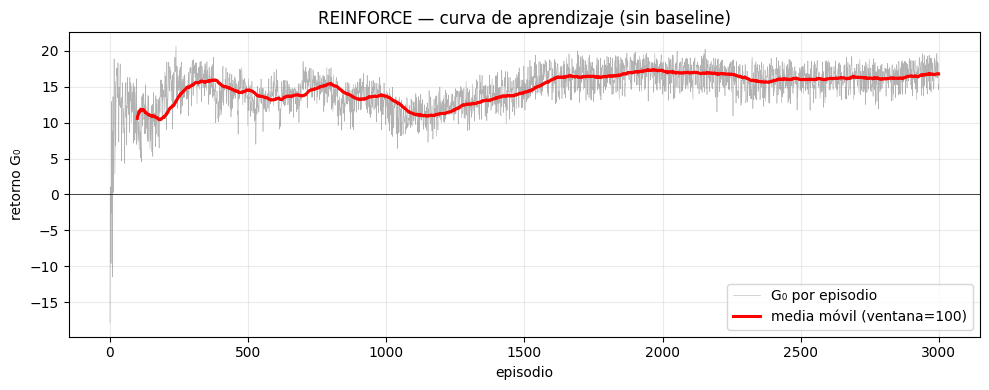

In [6]:
curve = hw_a.returns_curve(window=100)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(curve["episode"], curve["G0"], color="gray", lw=0.4, alpha=0.6, label="G₀ por episodio")
ax.plot(curve["episode"], curve["rolling"], color="red", lw=2.2, label="media móvil (ventana=100)")
ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel("episodio"); ax.set_ylabel("retorno G₀")
ax.set_title("REINFORCE — curva de aprendizaje (sin baseline)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### El policy aprendido — visualizado

Compara los dos gráficos: antes (todo uniforme) y después de 3000 episodios. Lo que típicamente verás:

- Cerca de la **zanja roja** ($x \approx 0.75$): las flechas **azules** (left) dominan — el agente "huye" hacia la izquierda.
- Cerca de la **autopista verde** ($x \approx 0.25$): las flechas **rojas** (up) dominan o se mantienen — quedarse pagado.
- En medio, hay un **gradiente espacial** suave: el modelo aprendió un *mapa* de qué hacer en cada zona.

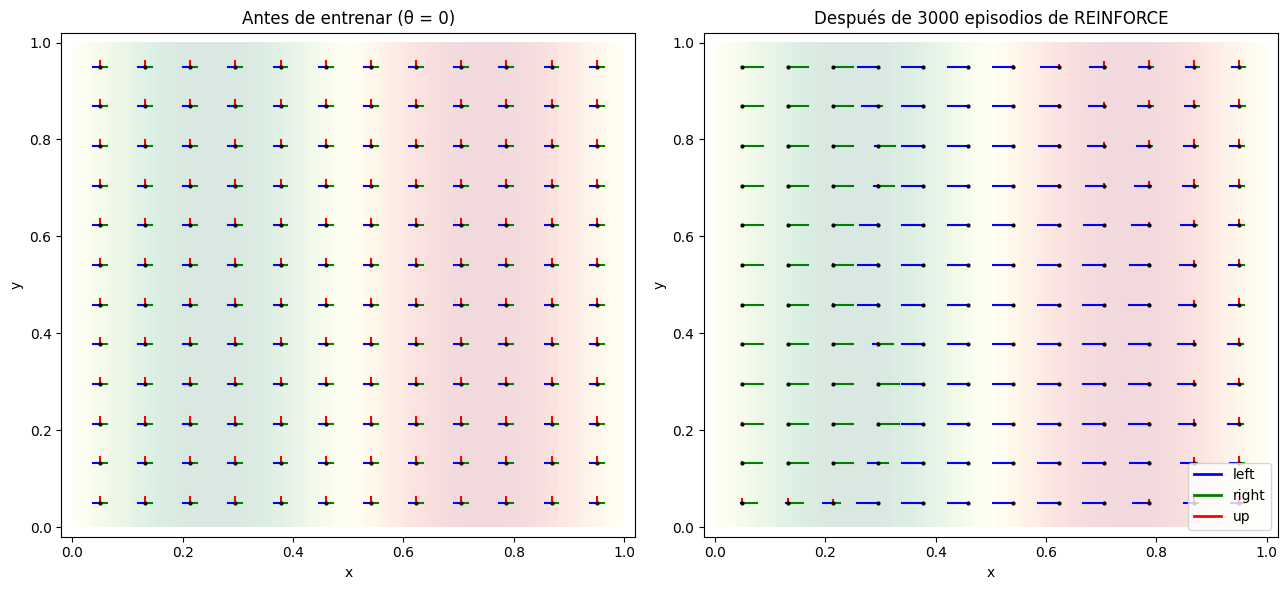

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
hw_init = WindyHighway(alpha=0.1, distance_scaler=0.15, protos_per_dim=5, seed=1)
plot_policy(hw_init, axes[0], title="Antes de entrenar (θ = 0)")
plot_policy(hw_a,    axes[1], title="Después de 3000 episodios de REINFORCE")
axes[1].legend(handles=[Line2D([0],[0],color=c,lw=2,label=l) for c,l in
                        [("blue","left"),("green","right"),("red","up")]], loc="lower right")
plt.tight_layout()
plt.show()

### Trayectorias del policy entrenado

Muestreamos varios episodios con el policy aprendido. Mira cómo todos **terminan cerca de $x \approx 0.25$** — el agente ha aprendido a sesgar consistentemente hacia la autopista, a pesar del viento que lo empuja hacia la derecha al principio.

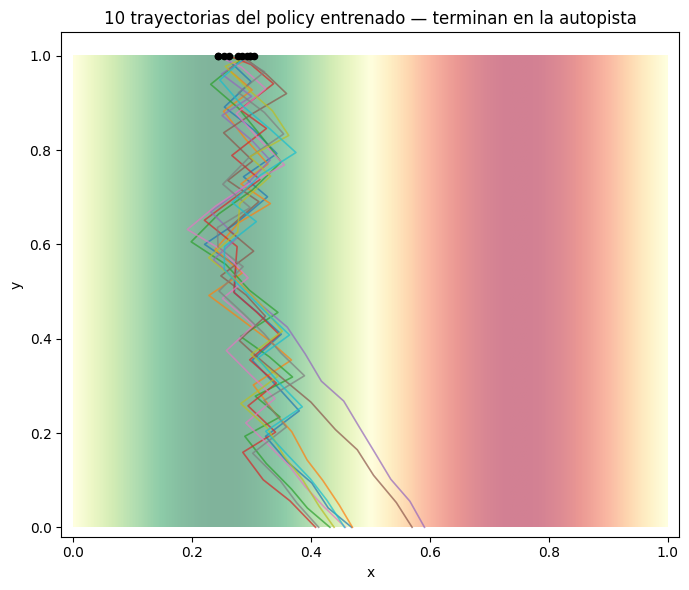

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
land = hw_a.reward_landscape(n_grid=200)
ax.imshow(land["R"], origin="lower", extent=[0, 1, 0, 1], cmap="RdYlGn", alpha=0.5, aspect="auto")
for k in range(10):
    states, _, _, returns = hw_a.play_episode()
    ax.plot(states[:, 0], states[:, 1], lw=1.2, alpha=0.7)
    ax.scatter(states[-1, 0], states[-1, 1], color="black", s=20, zorder=3)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.05)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("10 trayectorias del policy entrenado — terminan en la autopista")
plt.tight_layout()
plt.show()

## El problema de varianza — y el baseline

La curva de aprendizaje arriba se mueve, pero **fluctúa muchísimo**. Eso no es porque el problema sea difícil — es porque el estimador de gradiente de REINFORCE tiene **alta varianza**. Cualquier episodio con un buen golpe de suerte arrastra al gradiente.

El truco para reducir varianza sin sesgar el estimador: **restar un baseline** $b(s)$ que solo dependa del estado.

$$\nabla_\theta J(\theta) = \mathbb{E}\!\left[ \sum_t \big( G_t - b(s_t) \big) \, \nabla_\theta \log \pi_\theta(a_t | s_t) \right]$$

El mejor baseline (matemáticamente) es la **función de valor** del policy actual, $V^\pi(s) = \mathbb{E}[G_t | s_t = s]$. La cantidad $G_t - V(s_t)$ es la **ventaja** $A_t$ — *qué tan mejor que la media* fue la acción en ese estado. 

> **Conexión con `04_ppo`:** esto es exactamente lo que el **crítico** del actor-crítico hace en PPO. La fórmula que ves arriba es la motivación del crítico. PPO añade la complicación adicional de *clipping*, pero el ingrediente "resta un valor aprendido" es el mismo.

Aprendemos $V$ junto al policy con regresión RBF: misma idea, otra capa de features.

### Cuándo importa el baseline — un experimento

Si todas las recompensas son positivas, el gradiente sin baseline siempre empuja la log-prob hacia *arriba* de todas las acciones (solo cambia la magnitud). Eso es lentísimo. Para forzar este caso, sumamos un `reward_shift` grande — las recompensas pasan de estar en $[-1, +1]$ a estar en $[+4, +6]$.

Compara los dos entrenamientos en igualdad de condiciones: misma seed, mismo $\alpha$, mismas features. Solo cambia si usamos baseline o no.

In [9]:
SHIFT = 5.0

hw_no_b = WindyHighway(
    alpha=0.1, distance_scaler=0.15, protos_per_dim=5, seed=1,
    reward_shift=SHIFT, with_baseline=False,
)
hw_with_b = WindyHighway(
    alpha=0.1, distance_scaler=0.15, protos_per_dim=5, seed=1,
    reward_shift=SHIFT, with_baseline=True,
    alpha_value=0.1, distance_scaler_value=0.2, protos_per_dim_value=3,
)

hw_no_b.run(num_episodes=2000)
hw_with_b.run(num_episodes=2000)

episodes:   0%|          | 0/2000 [00:00<?, ?it/s]

episodes:   3%|▎         | 57/2000 [00:00<00:03, 569.69it/s]

episodes:   6%|▌         | 116/2000 [00:00<00:03, 578.81it/s]

episodes:  11%|█         | 217/2000 [00:00<00:02, 774.98it/s]

episodes:  16%|█▌        | 310/2000 [00:00<00:02, 834.14it/s]

...

episodes:  86%|████████▋ | 1729/2000 [00:02<00:00, 719.87it/s]

episodes:  90%|█████████ | 1802/2000 [00:02<00:00, 700.98it/s]

episodes:  94%|█████████▎| 1873/2000 [00:02<00:00, 663.05it/s]

episodes:  98%|█████████▊| 1956/2000 [00:02<00:00, 703.73it/s]

episodes: 100%|██████████| 2000/2000 [00:02<00:00, 672.69it/s]

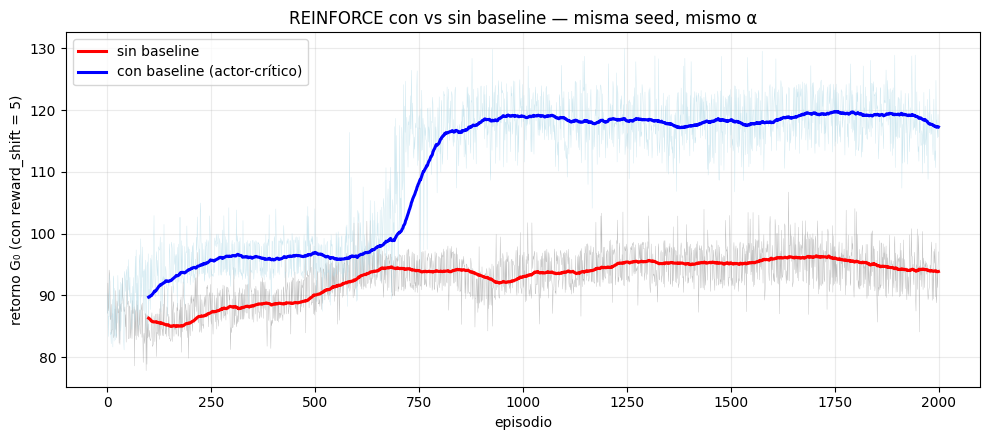

Sin baseline — últimos 500: media=+95.15, std=3.45
Con baseline — últimos 500: media=+118.70, std=3.97


In [10]:
c1 = hw_no_b.returns_curve(window=100)
c2 = hw_with_b.returns_curve(window=100)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(c1["episode"], c1["G0"], color="gray",      lw=0.3, alpha=0.5)
ax.plot(c2["episode"], c2["G0"], color="lightblue", lw=0.3, alpha=0.6)
ax.plot(c1["episode"], c1["rolling"], color="red",  lw=2.2, label="sin baseline")
ax.plot(c2["episode"], c2["rolling"], color="blue", lw=2.2, label="con baseline (actor-crítico)")
ax.set_xlabel("episodio"); ax.set_ylabel("retorno G₀ (con reward_shift = 5)")
ax.set_title("REINFORCE con vs sin baseline — misma seed, mismo α")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Quantitative comparison of variance on the last 500 episodes
import numpy as np
tail1 = np.array(hw_no_b.G0s[-500:])
tail2 = np.array(hw_with_b.G0s[-500:])
print(f"Sin baseline — últimos 500: media={tail1.mean():+.2f}, std={tail1.std():.2f}")
print(f"Con baseline — últimos 500: media={tail2.mean():+.2f}, std={tail2.std():.2f}")

**Qué deberías observar:**

1. La curva **roja (sin baseline)** sube lentamente o se queda plana. Con `reward_shift = 5`, todas las recompensas son positivas y el gradiente empuja a todas las acciones hacia arriba — el aprendizaje se diluye.
2. La curva **azul (con baseline)** sube **mucho más rápido** y aterriza más alta. La resta del valor anula el efecto del `reward_shift` (`G_t - V(s_t)` deja de estar inflado).
3. La **desviación estándar del retorno** en los últimos 500 episodios es bastante menor con baseline — la *señal* del gradiente está más limpia.

Esta es **toda** la motivación del crítico en PPO. En LLMs no hay un `reward_shift` literal, pero la recompensa del modelo de recompensa tiene una *escala arbitraria* (es un escalar aprendido). Un baseline aprendido cancela ese sesgo de escala.

## Conexión con los siguientes notebooks

Mapeo conceptual entre lo que viste aquí y lo que viene en `04_ppo` / `06_grpo`:

| Windy Highway | LLM RLHF |
|---|---|
| Estado $s = (x, y)$ | Contexto de tokens generados hasta ahora |
| Acción $a \in \{$left, right, up$\}$ | Siguiente token (de un vocabulario de ~50k) |
| Recompensa $r(x) = \sin(2\pi x)$ | Score escalar del Reward Model al final de la respuesta |
| Trayectoria $\tau$ | Respuesta completa (`prompt + tokens generados`) |
| Policy RBF + softmax | Transformer + softmax sobre el vocabulario |
| Baseline $V_\phi(s)$ | Cabeza de valor del PPOModel (mismo backbone, otra cabeza) |
| REINFORCE update | Policy gradient *con clipping* (la complicación de PPO) |
| Group baseline (GRPO) | En vez de aprender $V$, *promediar* G muestras del mismo prompt |

Tres ideas que importan más que la matemática específica:

1. **El gradiente no necesita ser "correcto" para cada token** — solo necesita estar *sesgado a favor* del retorno alto en expectativa.
2. **La varianza es el enemigo número uno** — todas las técnicas (baselines, clipping, KL penalty, blanqueo) son herramientas para domarla.
3. **El reward es solo una señal escalar**. La calidad de tu RM (notebook 03) es el techo de todo lo que pueda lograr PPO/GRPO. Si el RM premia ruido, el policy aprende a producir ruido — eso es *reward hacking*, y empezó siendo una elección de algoritmo.

## Siguiente: `01_pretrained.ipynb`

Ya viste policy gradients en miniatura. Ahora cambiamos del cuadrado `[0,1]²` a un transformer real, y empezamos por entender qué hace un LLM *sin alinear*.